# Compare two LV4 history files (Apr 5 start)

Side-by-side time series of `Hwave`, `ubar`, `vbar`, `zeta` at the center of the domain for two `LV4_ocean_his_202604050000.nc` files:

- **A** (`fillin`): `/scratch/PFM_Simulations/LV4_fillin_Apr26/my_archives/LV4_ocean_his_202604050000.nc`
- **B** (`archive`): `/dataSIO/PFM_Simulations/Archive/LV4_His/LV4_ocean_his_202604050000.nc`


In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

fa = '/scratch/PFM_Simulations/LV4_fillin_Apr26/my_archives/LV4_ocean_his_202604050000.nc'
fb = '/dataSIO/PFM_Simulations/Archive/LV4_His/LV4_ocean_his_202604050000.nc'

dsa = xr.open_dataset(fa, decode_times=True)
dsb = xr.open_dataset(fb, decode_times=True)
print('A (fillin):  ', dict(dsa.sizes))
print('B (archive): ', dict(dsb.sizes))

A (fillin):   {'tracer': 4, 'boundary': 4, 's_rho': 10, 's_w': 11, 'eta_rho': 1141, 'xi_rho': 486, 'eta_u': 1141, 'xi_u': 485, 'eta_v': 1140, 'xi_v': 486, 'eta_psi': 1140, 'xi_psi': 485, 'ocean_time': 121}
B (archive):  {'tracer': 4, 'boundary': 4, 's_rho': 10, 's_w': 11, 'eta_rho': 1141, 'xi_rho': 486, 'eta_u': 1141, 'xi_u': 485, 'eta_v': 1140, 'xi_v': 486, 'eta_psi': 1140, 'xi_psi': 485, 'ocean_time': 121}


In [3]:
# pick the center of the domain (use file A to get sizes; B is the same grid)
ny_rho, nx_rho = dsa.sizes['eta_rho'], dsa.sizes['xi_rho']
ny_u,   nx_u   = dsa.sizes['eta_u'],   dsa.sizes['xi_u']
ny_v,   nx_v   = dsa.sizes['eta_v'],   dsa.sizes['xi_v']

jr, ir = ny_rho // 2, nx_rho // 2  # rho/Hwave/zeta center
ju, iu = ny_u   // 2, nx_u   // 2  # ubar center
jv, iv = ny_v   // 2, nx_v   // 2  # vbar center
print(f'rho center (j,i) = ({jr},{ir});  u center = ({ju},{iu});  v center = ({jv},{iv})')


rho center (j,i) = (570,243);  u center = (570,242);  v center = (570,243)


In [7]:
def pull(ds):
    return {
        'time':   ds['ocean_time'].values,
        'Hwave':  ds['Hwave'].isel(eta_rho=jr, xi_rho=ir).values,
        'ubar':   ds['ubar'].isel(eta_u=ju,   xi_u=iu).values,
        'vbar':   ds['vbar'].isel(eta_v=jv,   xi_v=iv).values,
        'zeta':   ds['zeta'].isel(eta_rho=jr, xi_rho=ir).values,
        'dye_01': ds['dye_01'].isel(s_rho=-1, eta_rho=jr, xi_rho=ir).values,
        'dye_02': ds['dye_02'].isel(s_rho=-1, eta_rho=jr, xi_rho=ir).values,
    }

a = pull(dsa)
b = pull(dsb)
print('A time range:', a['time'][0], '...', a['time'][-1], f"({len(a['time'])} steps)")
print('B time range:', b['time'][0], '...', b['time'][-1], f"({len(b['time'])} steps)")


A time range: 2026-04-05T00:00:00.000000000 ... 2026-04-10T00:00:00.000000000 (121 steps)
B time range: 2026-04-05T00:00:00.000000000 ... 2026-04-10T00:00:00.000000000 (121 steps)


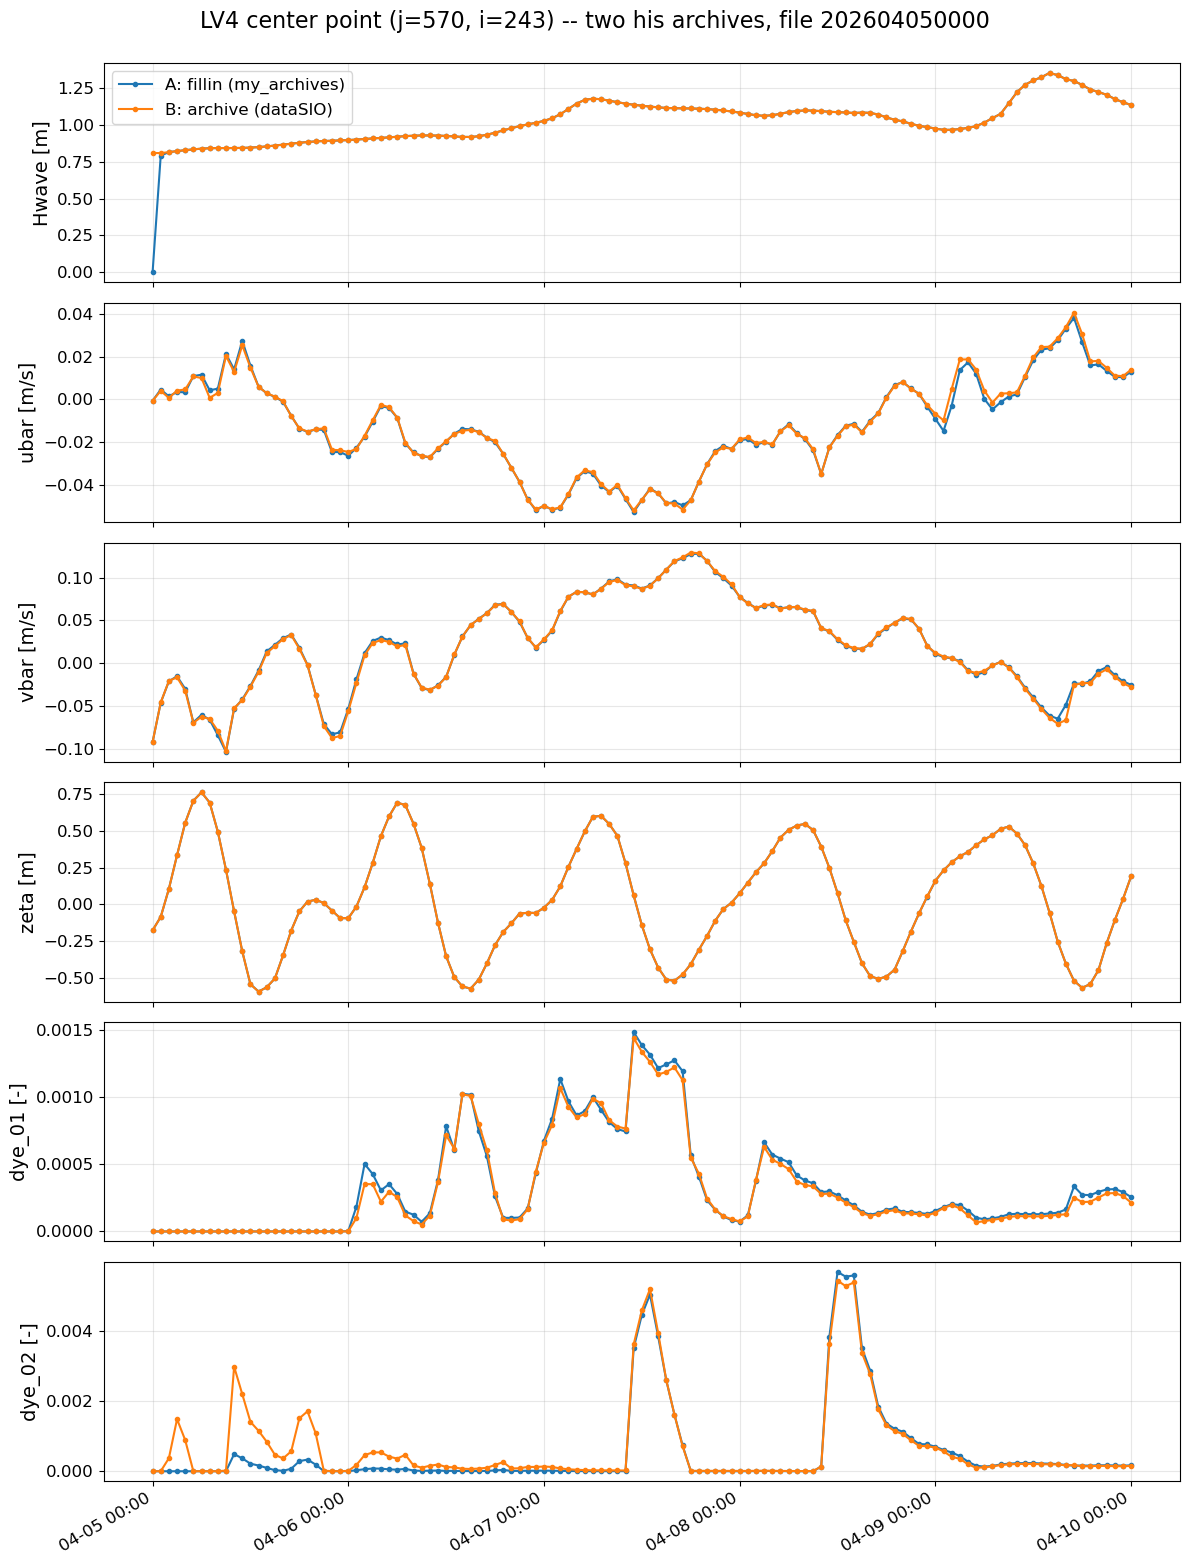

In [8]:
vars_to_plot = ['Hwave','ubar','vbar','zeta','dye_01','dye_02']
units = {'Hwave':'m','ubar':'m/s','vbar':'m/s','zeta':'m','dye_01':'-','dye_02':'-'}

ca = 'tab:blue'    # A (fillin)
cb = 'tab:orange'  # B (archive)

LBL_FS, TICK_FS, LEG_FS, TITLE_FS = 14, 12, 12, 16

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(12, 2.6*len(vars_to_plot)), sharex=True)
for ax, v in zip(axes, vars_to_plot):
    ax.plot(a['time'], a[v], '-o', ms=3, color=ca, label='A: fillin (my_archives)')
    ax.plot(b['time'], b[v], '-o', ms=3, color=cb, label='B: archive (dataSIO)')
    ax.set_ylabel(f'{v} [{units[v]}]', fontsize=LBL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(True, alpha=0.3)
axes[0].legend(loc='best', fontsize=LEG_FS)
axes[-1].xaxis.set_major_formatter(DateFormatter('%m-%d %H:%M'))
fig.autofmt_xdate()
fig.suptitle(f'LV4 center point (j={jr}, i={ir}) -- two his archives, file 202604050000', y=1.0, fontsize=TITLE_FS)
fig.tight_layout()
plt.show()


## Difference (A - B) over time

In [ ]:
fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(12, 2.0*len(vars_to_plot)), sharex=True)
for ax, v in zip(axes, vars_to_plot):
    ax.plot(a['time'], a[v] - b[v], '-o', ms=3, color='k')
    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_ylabel(f'{v} A-B [{units[v]}]', fontsize=LBL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(True, alpha=0.3)
axes[-1].xaxis.set_major_formatter(DateFormatter('%m-%d %H:%M'))
fig.autofmt_xdate()
fig.suptitle('Difference A - B (center point) for each variable', y=1.0, fontsize=TITLE_FS)
fig.tight_layout()
plt.show()


In [ ]:
# Quick numeric summary per variable: max |A-B|, RMSE, correlation
print(f"{'var':6s} {'max|A-B|':>12s} {'RMSE':>12s} {'corr':>8s}")
for v in vars_to_plot:
    diff = a[v] - b[v]
    rmse = float(np.sqrt(np.mean(diff**2)))
    corr = float(np.corrcoef(a[v], b[v])[0,1]) if np.std(a[v])>0 and np.std(b[v])>0 else float('nan')
    print(f'{v:6s} {float(np.max(np.abs(diff))):12.6g} {rmse:12.6g} {corr:8.4f}')